# Issue #4: Data Preprocessing – EV Charging Sessions

**Input:** `acn_structured_sessions.csv` (Issue #3)  
**Outputs:** `acn_clean_sessions.csv`, `acn_flagged_sessions.csv`, `preprocessing_summary.csv`, `preprocessing_report.md`

**Rules for this notebook**
- Every removal is a named rule with its threshold defined in one place; every removed row is saved with its reason.
- Thresholds are set *after* the distributions are inspected (Section 4).
- Rules are labelled **ACTIVE** (removed rows), **guard** (sanity check expected to affect nothing) or **fix** (value corrected, row kept).
- The final summary (Section 10) is generated from the data, so its numbers always match the outputs above it.

In [1]:
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 60)

IN_FILE = "../acn_structured_sessions.csv"
df = pd.read_csv(IN_FILE)
raw_rows = len(df)
print("Loaded shape:", df.shape)
df.head(3)

Loaded shape: (14400, 13)


,_id,sessionID,userID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,timezone,userInputs
0,5bc90cb9f9af8b0d7fe77cd2,2_39_78_362_2018-04-25 11:08:04.400812,NaN,2-39-78-362,CA-496,2,39,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,America/Los_Angeles,NaN
1,5bc90cb9f9af8b0d7fe77cd3,2_39_95_27_2018-04-25 13:45:09.617470,NaN,2-39-95-27,CA-319,2,39,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,America/Los_Angeles,NaN
2,5bc90cb9f9af8b0d7fe77cd4,2_39_79_380_2018-04-25 13:45:49.962001,NaN,2-39-79-380,CA-489,2,39,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,America/Los_Angeles,NaN


## 1. Missing values

In [2]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
missing

,missing,pct_missing,dtype
_id,0,0.00,str
sessionID,0,0.00,str
userID,12670,87.99,float64
stationID,0,0.00,str
spaceID,0,0.00,str
siteID,0,0.00,int64
clusterID,0,0.00,int64
connectionTime,0,0.00,str
disconnectTime,0,0.00,str
doneChargingTime,6,0.04,str


`userID` and `userInputs` are populated only for a minority of sessions. `doneChargingTime` has very few gaps. Treatment is decided in Section 6.

In [3]:
# One real (non-null) userInputs value, to check the parser in Section 7 against the actual format
sample = df["userInputs"].dropna().iloc[0] if df["userInputs"].notna().any() else None
print(type(sample))
print(sample)

<class 'str'>
[{'userID': 22, 'milesRequested': 170, 'WhPerMile': 350, 'minutesAvailable': 550, 'modifiedAt': 'Mon, 30 Apr 2018 15:08:54 GMT', 'paymentRequired': True, 'requestedDeparture': 'Tue, 01 May 2018 00:17:49 GMT', 'kWhRequested': 59.5}]


## 2. Duplicate records

In [4]:
dup_report = {
    "duplicate _id": int(df.duplicated("_id").sum()),
    "duplicate sessionID": int(df.duplicated("sessionID").sum()),
    "duplicate stationID + connectionTime": int(df.duplicated(["stationID", "connectionTime"]).sum()),
    "fully identical rows": int(df.duplicated().sum()),
}
dup_report

{'duplicate _id': 0,
 'duplicate sessionID': 0,
 'duplicate stationID + connectionTime': 0,
 'fully identical rows': 0}

## 3. Timestamp validation and time coverage

In [5]:
TS_FORMAT = "%a, %d %b %Y %H:%M:%S GMT"
LOCAL_TZ = "America/Los_Angeles"
ts_cols = ["connectionTime", "disconnectTime", "doneChargingTime"]

for c in ts_cols:
    df[c] = pd.to_datetime(df[c], format=TS_FORMAT, errors="coerce", utc=True)

print("Unparseable / missing after parsing:")
print(df[ts_cols].isna().sum())

print("\nRange (UTC):  ", df["connectionTime"].min(), "->", df["connectionTime"].max())
print("Range (local):", df["connectionTime"].min().tz_convert(LOCAL_TZ), "->",
      df["connectionTime"].max().tz_convert(LOCAL_TZ))

Unparseable / missing after parsing:
connectionTime      0
disconnectTime      0
doneChargingTime    6
dtype: int64

Range (UTC):   2018-04-25 11:08:04+00:00 -> 2019-01-29 18:40:47+00:00
Range (local): 2018-04-25 04:08:04-07:00 -> 2019-01-29 10:40:47-08:00


In [6]:
checks = {
    "disconnect <= connect": int((df["disconnectTime"] <= df["connectionTime"]).sum()),
    "doneCharging before connect": int((df["doneChargingTime"] < df["connectionTime"]).sum()),
    "doneCharging > disconnect + 5 min": int((df["doneChargingTime"] > df["disconnectTime"] + pd.Timedelta(minutes=5)).sum()),
}
checks

{'disconnect <= connect': 0,
 'doneCharging before connect': 18,
 'doneCharging > disconnect + 5 min': 0}

connectionTime
2018-04     270
2018-05    1776
2018-06    1845
2018-07    2053
2018-08    2430
2018-09    2315
2018-10    2424
2018-11    1187
2019-01     100
Freq: M

Coverage: 279 days (~9.2 months)


C:\Users\GNANESH KHANDAVILLI\AppData\Local\Temp\ipykernel_13088\237524342.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  local_month = df["connectionTime"].dt.tz_convert(LOCAL_TZ).dt.to_period("M")


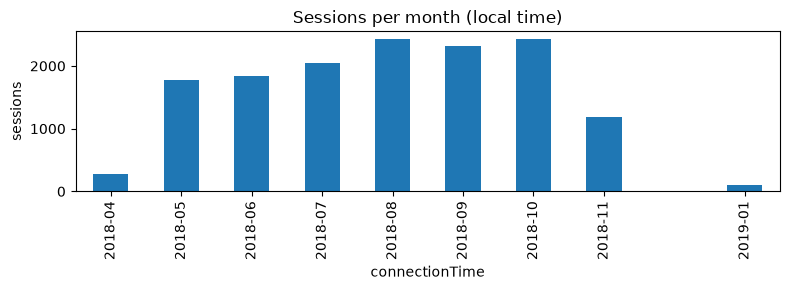

In [7]:
# Coverage: sessions per local month. A hard stop or gaps here limit what the forecasting stage can claim.
local_month = df["connectionTime"].dt.tz_convert(LOCAL_TZ).dt.to_period("M")
monthly = local_month.value_counts().sort_index()
print(monthly.to_string())

span_days = (df["connectionTime"].max() - df["connectionTime"].min()).days
print(f"\nCoverage: {span_days} days (~{span_days/30.4:.1f} months)")

ax = monthly.plot(kind="bar", figsize=(8, 3), title="Sessions per month (local time)")
ax.set_ylabel("sessions"); plt.tight_layout(); plt.show()

> **Limitation:** the API reported 31,424 sessions in total; this dataset holds the earliest 14,400 (collection stopped on repeated HTTP 502 errors at deep page offsets). It therefore covers about 9 months only, so **no full annual cycle** is available. Daily and weekly patterns are well supported; annual seasonality is not. Completing the collection is tracked as a separate issue; this notebook is written to be re-run unchanged on the larger file.

## 4. Numerical variables (evidence for thresholds)

       kWhDelivered  connected_h
count     14400.000    14400.000
mean          9.000        5.923
std           6.986        6.544
min           0.501        0.088
1%            0.690        0.181
5%            1.145        0.517
50%           7.474        4.726
95%          19.447       12.629
99%          38.862       24.106
max          75.528      245.269


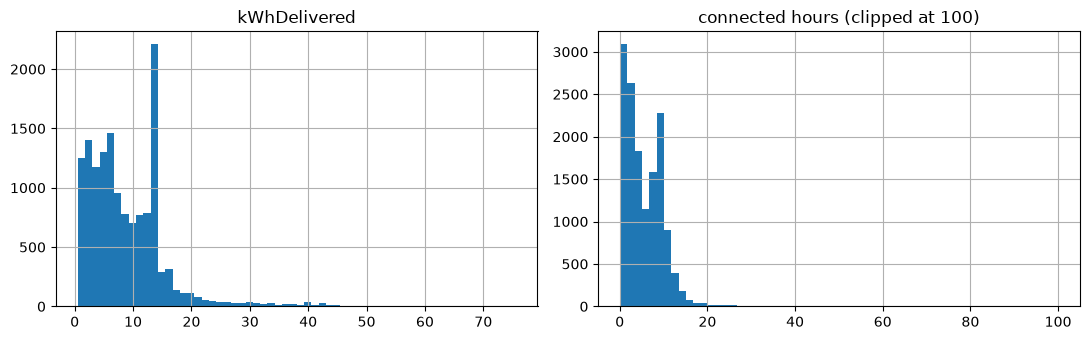

In [8]:
df["kWhDelivered"] = pd.to_numeric(df["kWhDelivered"], errors="coerce")
df["connected_h"] = (df["disconnectTime"] - df["connectionTime"]).dt.total_seconds() / 3600

print(df[["kWhDelivered", "connected_h"]].describe(percentiles=[.01, .05, .5, .95, .99]).round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["kWhDelivered"].hist(bins=60, ax=ax[0]); ax[0].set_title("kWhDelivered")
df["connected_h"].clip(upper=100).hist(bins=60, ax=ax[1]); ax[1].set_title("connected hours (clipped at 100)")
plt.tight_layout(); plt.show()

In [9]:
print("kWh < 0.1:          ", int((df["kWhDelivered"] < 0.1).sum()))
print("kWh > 100:          ", int((df["kWhDelivered"] > 100).sum()))
print("connected < 1 min:  ", int((df["connected_h"] * 60 < 1).sum()))
print("connected > 72 h:   ", int((df["connected_h"] > 72).sum()))
print("connected > 48 h:   ", int((df["connected_h"] > 48).sum()))
print("connected > 24 h:   ", int((df["connected_h"] > 24).sum()))

kWh < 0.1:           0
kWh > 100:           0
connected < 1 min:   0
connected > 72 h:    21
connected > 48 h:    52
connected > 24 h:    149


### 4a. Two patterns to understand before modelling

1. A sharp spike in `kWhDelivered` around 13–14 kWh.
2. A bimodal connection-time distribution (short stays vs. full-workday stays).

These are findings, not errors — nothing is removed here. Their numbers in the final summary are recomputed on the cleaned data.

In [10]:
spike = df[df["kWhDelivered"].between(13, 14)]
print(f"Sessions in 13-14 kWh: {len(spike)} ({len(spike)/len(df):.1%} of all)")

local_hr = df["connectionTime"].dt.tz_convert(LOCAL_TZ).dt.hour
print("\nSpike sessions - top stations:")
print(spike["stationID"].value_counts().head(5).to_string())
print("\nSpike sessions - arrival hour (local), top 5:")
print(local_hr.loc[spike.index].value_counts().head(5).to_string())
print("\nSpike sessions - share with userID:", round(spike["userID"].notna().mean(), 3),
      "| all sessions:", round(df["userID"].notna().mean(), 3))
print("Spike sessions - median connected hours:", round(spike["connected_h"].median(), 2),
      "| all sessions:", round(df["connected_h"].median(), 2))

Sessions in 13-14 kWh: 2046 (14.2% of all)

Spike sessions - top stations:
stationID
2-39-131-30    101
2-39-127-19     98
2-39-139-28     95
2-39-123-23     87
2-39-125-21     86

Spike sessions - arrival hour (local), top 5:
connectionTime
8     349
9     239
7     163
17    161
10    146

Spike sessions - share with userID: 0.045 | all sessions: 0.12
Spike sessions - median connected hours: 6.57 | all sessions: 4.73


In [11]:
short = df["connected_h"] < 3
print(f"Short stays (<3 h): {short.mean():.1%}  | median kWh: {df.loc[short,'kWhDelivered'].median():.2f}")
print(f"Long stays (>=3 h): {(~short).mean():.1%} | median kWh: {df.loc[~short,'kWhDelivered'].median():.2f}")

Short stays (<3 h): 36.1%  | median kWh: 4.78
Long stays (>=3 h): 63.9% | median kWh: 10.25


> **Caution:** the top five stations will always hold more than 5/54 of the spike sessions simply because they are the top five. That is not evidence that the spike is station-specific. To test it properly, compare each station's spike share against that station's own total sessions (not done here; flagged for the analytics stage).

## 5. Categorical variables

In [12]:
for c in ["siteID", "clusterID", "timezone"]:
    print(c, "->", df[c].nunique(), "unique:", df[c].unique()[:5])
print("stationID unique:", df["stationID"].nunique(), "| spaceID unique:", df["spaceID"].nunique())
df["stationID"].value_counts().describe()

siteID -> 1 unique: [2]
clusterID -> 1 unique: [39]
timezone -> 1 unique: <ArrowStringArray>
['America/Los_Angeles']
Length: 1, dtype: str
stationID unique: 54 | spaceID unique: 54


count     54.000000
mean     266.666667
std      147.901165
min        4.000000
25%      159.500000
50%      260.500000
75%      356.750000
max      664.000000
Name: count, dtype: float64

## 6. Thresholds and cleaning

**Active rule:** connection time over 72 h — the only rule expected to remove rows on this data. Justification: the 99th percentile is ≈24 h and the maximum ≈245 h; sessions beyond 72 h are not daily-demand events (vehicle left plugged in or unplug not recorded) and are ≈0.15% of rows.

**Guards:** the remaining removal rules are sanity checks. The observed kWh range is ≈0.5–75.5 and the shortest connection ≈5 minutes, so they are expected to affect nothing. They stay in so the pipeline is safe when more data is added.

In [13]:
MIN_KWH = 0.1            # guard
MAX_KWH = 100.0          # guard
MIN_CONNECT_MIN = 1.0    # guard
MAX_CONNECT_H = 72.0     # ACTIVE
POWER_MAX_KW = 10.0      # used in Section 8 (value nulled, row kept)

In [14]:
waterfall = [("loaded", "-", len(df), 0)]
flagged = []

def drop(mask, reason, kind):
    """Remove rows where mask is True, save them with the reason, log the count."""
    global df
    n = int(mask.sum())
    if n:
        bad = df[mask].copy()
        bad["drop_reason"] = reason
        flagged.append(bad)
        df = df[~mask].copy()
    waterfall.append((reason, kind, len(df), n))

drop(df.duplicated("_id"), "duplicate _id", "guard")
drop(df.duplicated("sessionID"), "duplicate sessionID", "guard")
drop(df.duplicated(["stationID", "connectionTime"]), "duplicate station+connectionTime", "guard")

drop(df["connectionTime"].isna() | df["disconnectTime"].isna(), "unparseable connect/disconnect time", "guard")
drop(df["disconnectTime"] <= df["connectionTime"], "disconnect not after connect", "guard")

# doneChargingTime: keep the session. Record WHY it is empty before blanking anything.
done_bad = df["doneChargingTime"].notna() & (
    (df["doneChargingTime"] < df["connectionTime"]) |
    (df["doneChargingTime"] > df["disconnectTime"] + pd.Timedelta(minutes=5))
)
df["done_time_inconsistent"] = done_bad                    # source value existed but was impossible
df["done_time_missing"] = df["doneChargingTime"].isna()    # source value never existed
df.loc[done_bad, "doneChargingTime"] = pd.NaT
waterfall.append(("doneChargingTime outside plug-in window -> NaT (rows kept)", "fix", len(df), int(done_bad.sum())))

drop(df["kWhDelivered"].isna(), "kWhDelivered missing/non-numeric", "guard")
drop(df["kWhDelivered"] < MIN_KWH, f"kWhDelivered < {MIN_KWH}", "guard")
drop(df["kWhDelivered"] > MAX_KWH, f"kWhDelivered > {MAX_KWH}", "guard")

df["connected_h"] = (df["disconnectTime"] - df["connectionTime"]).dt.total_seconds() / 3600
drop(df["connected_h"] * 60 < MIN_CONNECT_MIN, f"connected < {MIN_CONNECT_MIN} min", "guard")
drop(df["connected_h"] > MAX_CONNECT_H, f"connected > {MAX_CONNECT_H} h", "ACTIVE")

wf = pd.DataFrame(waterfall, columns=["step", "kind", "rows_remaining", "rows_affected"])
wf

,step,kind,rows_remaining,rows_affected
0,loaded,-,14400,0
1,duplicate _id,guard,14400,0
2,duplicate sessionID,guard,14400,0
3,duplicate station+connectionTime,guard,14400,0
4,unparseable connect/disconnect time,guard,14400,0
5,disconnect not after connect,guard,14400,0
6,doneChargingTime outside plug-in window -> NaT...,fix,14400,18
7,kWhDelivered missing/non-numeric,guard,14400,0
8,kWhDelivered < 0.1,guard,14400,0
9,kWhDelivered > 100.0,guard,14400,0


In [15]:
print("Rows removed by ACTIVE rules:", int(wf.loc[wf.kind == "ACTIVE", "rows_affected"].sum()))
print("Rows removed by guards (expected 0):", int(wf.loc[wf.kind == "guard", "rows_affected"].sum()))
print("doneChargingTime originally missing (kept):", int(df["done_time_missing"].sum()))
print("doneChargingTime inconsistent -> blanked (kept):", int(df["done_time_inconsistent"].sum()))

Rows removed by ACTIVE rules: 21
Rows removed by guards (expected 0): 0
doneChargingTime originally missing (kept): 6
doneChargingTime inconsistent -> blanked (kept): 18


## 7. Preprocessing techniques

- Timestamps converted from UTC to local time (`America/Los_Angeles`)
- `userInputs` flattened (latest entry) into `ui_*` columns; flags added for rows with no user data
- `userID` kept as an identifier (it became a float in the CSV)
- Columns that carry no information are dropped and listed (nearly-empty `ui_*` columns; `ui_userID` if it duplicates `userID`)
- Minimal derived fields used for validation: durations, average power, local hour and weekday. Fuller feature engineering belongs to the next stage.

In [16]:
for c in ts_cols:
    df[c + "_local"] = df[c].dt.tz_convert(LOCAL_TZ)

df["charging_h"] = (df["doneChargingTime"] - df["connectionTime"]).dt.total_seconds() / 3600
df["avg_power_kW"] = df["kWhDelivered"] / df["charging_h"].where(df["charging_h"] > 0)
df["hour"] = df["connectionTime_local"].dt.hour
df["dayofweek"] = df["connectionTime_local"].dt.dayofweek
df["date"] = df["connectionTime_local"].dt.date

def parse_user_inputs(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return {}
    try:
        val = ast.literal_eval(raw) if isinstance(raw, str) else raw
    except (ValueError, SyntaxError):
        return {}
    if isinstance(val, list) and val and isinstance(val[-1], dict):
        return val[-1]
    return val if isinstance(val, dict) else {}

parsed = df["userInputs"].apply(parse_user_inputs)
flat = pd.DataFrame(parsed.tolist(), index=df.index)
print("userInputs keys found:", list(flat.columns))

df["has_user_input"] = parsed.apply(bool)
df["has_user_id"] = df["userID"].notna()
df["userID"] = df["userID"].astype("Int64").astype("string")

for c in flat.columns:
    df["ui_" + str(c)] = flat[c]

for c in ["ui_requestedDeparture", "ui_modifiedAt"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

df = df.drop(columns=["userInputs", "timezone"]).reset_index(drop=True)
df.head(3)

userInputs keys found: ['userID', 'milesRequested', 'WhPerMile', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'kWhRequested']


,_id,sessionID,userID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,connected_h,done_time_inconsistent,done_time_missing,connectionTime_local,disconnectTime_local,doneChargingTime_local,charging_h,avg_power_kW,hour,dayofweek,date,has_user_input,has_user_id,ui_userID,ui_milesRequested,ui_WhPerMile,ui_minutesAvailable,ui_modifiedAt,ui_paymentRequired,ui_requestedDeparture,ui_kWhRequested
0,5bc90cb9f9af8b0d7fe77cd2,2_39_78_362_2018-04-25 11:08:04.400812,<NA>,2-39-78-362,CA-496,2,39,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,2018-04-25 13:21:10+00:00,7.932,2.201667,False,False,2018-04-25 04:08:04-07:00,2018-04-25 06:20:10-07:00,2018-04-25 06:21:10-07:00,2.218333,3.575657,4,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
1,5bc90cb9f9af8b0d7fe77cd3,2_39_95_27_2018-04-25 13:45:09.617470,<NA>,2-39-95-27,CA-319,2,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,11.185000,False,False,2018-04-25 06:45:10-07:00,2018-04-25 17:56:16-07:00,2018-04-25 09:44:15-07:00,2.984722,3.354751,6,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
2,5bc90cb9f9af8b0d7fe77cd4,2_39_79_380_2018-04-25 13:45:49.962001,<NA>,2-39-79-380,CA-489,2,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,9.315278,False,False,2018-04-25 06:45:50-07:00,2018-04-25 16:04:45-07:00,2018-04-25 07:51:44-07:00,1.098333,4.786343,6,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN


In [17]:
# Drop columns that carry no information, and record what was dropped and why
dropped_cols = []

# (a) user-input columns that are almost entirely empty
for c in [c for c in df.columns if c.startswith("ui_")]:
    share = df[c].notna().mean()
    if share < 0.01:
        dropped_cols.append((c, f"only {int(df[c].notna().sum())} non-null values ({share:.2%})"))
        df = df.drop(columns=c)

# (b) ui_userID duplicates userID?
if "ui_userID" in df.columns:
    a = df["ui_userID"].astype("string").str.replace(r"\.0$", "", regex=True)
    same_presence = bool((a.notna() == df["userID"].notna()).all())
    both = a.notna() & df["userID"].notna()
    same_values = bool((a[both] == df.loc[both, "userID"]).all())
    print("ui_userID same rows populated as userID:", same_presence, "| same values:", same_values)
    if same_presence and same_values:
        dropped_cols.append(("ui_userID", "exact duplicate of userID"))
        df = df.drop(columns="ui_userID")

print("Dropped columns:")
for name, why in dropped_cols:
    print(f"  {name}: {why}")
print("Shape now:", df.shape)

ui_userID same rows populated as userID: True | same values: True
Dropped columns:
  ui_requestedDeparture: only 13 non-null values (0.09%)
  ui_userID: exact duplicate of userID
Shape now: (14379, 30)


## 8. Plausibility check: average charging power

count    14353.00
mean         3.65
std          9.23
min          0.04
50%          3.10
95%          6.59
99%          6.83
max       1033.01
Name: avg_power_kW, dtype: float64
avg_power_kW > 7 kW: 57 sessions (0.40%)
avg_power_kW > 10 kW: 24 sessions (0.17%)
avg_power_kW > 20 kW: 12 sessions (0.08%)


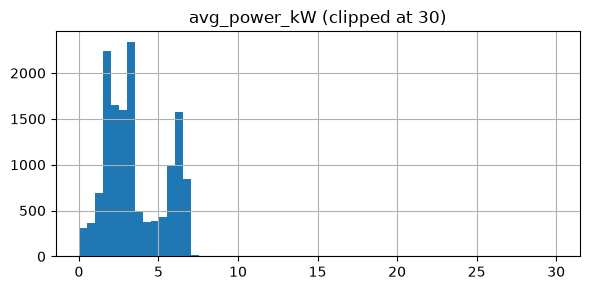

In [18]:
print(df["avg_power_kW"].describe(percentiles=[.5, .95, .99]).round(2))
for limit in (7, 10, 20):
    n = int((df["avg_power_kW"] > limit).sum())
    print(f"avg_power_kW > {limit} kW: {n} sessions ({n/len(df):.2%})")
df["avg_power_kW"].clip(upper=30).hist(bins=60, figsize=(6, 3))
plt.title("avg_power_kW (clipped at 30)"); plt.tight_layout(); plt.show()

Power above what the chargers can deliver is physically impossible and points to `doneChargingTime` landing seconds after connection. The sessions stay in the dataset; only the power value is nulled and flagged.

In [19]:
# Capture the evidence BEFORE nulling, so the summary can report it
power_info = {
    "p99": float(df["avg_power_kW"].quantile(0.99)),
    "max": float(df["avg_power_kW"].max()),
    "n_gt7": int((df["avg_power_kW"] > 7).sum()),
    "n_gt10": int((df["avg_power_kW"] > POWER_MAX_KW).sum()),
    "n_gt20": int((df["avg_power_kW"] > 20).sum()),
    "n_nonpositive_charging_h": int((df["charging_h"] <= 0).sum()),
    "n_no_doneTime": int(df["doneChargingTime"].isna().sum()),
}

df["power_implausible"] = df["avg_power_kW"] > POWER_MAX_KW
df.loc[df["power_implausible"], "avg_power_kW"] = np.nan
power_info["n_nulled"] = int(df["power_implausible"].sum())
power_info["n_power_null_total"] = int(df["avg_power_kW"].isna().sum())
power_info

{'p99': 6.83413436928702,
 'max': 1033.0122887864466,
 'n_gt7': 57,
 'n_gt10': 24,
 'n_gt20': 12,
 'n_nonpositive_charging_h': 2,
 'n_no_doneTime': 24,
 'n_nulled': 24,
 'n_power_null_total': 50}

## 9. Final checks, validation and save

In [20]:
print("Final shape:", df.shape)
print("Rows kept: {:.2f}% of {}".format(len(df) / raw_rows * 100, raw_rows))
print("Date range (local):", df["date"].min(), "->", df["date"].max())
print("Stations:", df["stationID"].nunique())
print("Sessions with userID:", int(df["has_user_id"].sum()), f"({df['has_user_id'].mean():.1%})")
nulls = df.isna().sum()
print("\nRemaining nulls:\n", nulls[nulls > 0].to_string())

Final shape: (14379, 31)
Rows kept: 99.85% of 14400
Date range (local): 2018-04-25 -> 2019-01-29
Stations: 54
Sessions with userID: 1727 (12.0%)

Remaining nulls:
 userID                    12652
doneChargingTime             24
doneChargingTime_local       24
charging_h                   24
avg_power_kW                 50
ui_milesRequested         12652
ui_WhPerMile              12652
ui_minutesAvailable       12652
ui_modifiedAt             12652
ui_paymentRequired        12652
ui_kWhRequested           12652


In [21]:
# Validation: these must all hold for the dataset to be called analysis-ready
assert not df["_id"].duplicated().any()
assert not df["sessionID"].duplicated().any()
assert (df["disconnectTime"] > df["connectionTime"]).all()
assert df["kWhDelivered"].between(MIN_KWH, MAX_KWH).all()
assert (df["connected_h"] <= MAX_CONNECT_H).all()
assert (df["avg_power_kW"].dropna() <= POWER_MAX_KW).all()
assert len(df) + sum(len(f) for f in flagged) == raw_rows, "rows lost or duplicated"
print("All validation checks passed")

All validation checks passed


In [22]:
summary = pd.DataFrame(waterfall, columns=["step", "kind", "rows_remaining", "rows_affected"])

df.to_csv("acn_clean_sessions.csv", index=False)
summary.to_csv("preprocessing_summary.csv", index=False)
n_flagged = sum(len(f) for f in flagged)
if flagged:
    pd.concat(flagged).to_csv("acn_flagged_sessions.csv", index=False)

print("Saved acn_clean_sessions.csv:", df.shape)
print("Saved preprocessing_summary.csv")
print("Saved acn_flagged_sessions.csv:", n_flagged, "rows")
summary

Saved acn_clean_sessions.csv: (14379, 31)
Saved preprocessing_summary.csv
Saved acn_flagged_sessions.csv: 21 rows


,step,kind,rows_remaining,rows_affected
0,loaded,-,14400,0
1,duplicate _id,guard,14400,0
2,duplicate sessionID,guard,14400,0
3,duplicate station+connectionTime,guard,14400,0
4,unparseable connect/disconnect time,guard,14400,0
5,disconnect not after connect,guard,14400,0
6,doneChargingTime outside plug-in window -> NaT...,fix,14400,18
7,kWhDelivered missing/non-numeric,guard,14400,0
8,kWhDelivered < 0.1,guard,14400,0
9,kWhDelivered > 100.0,guard,14400,0


## 10. Preprocessing summary (generated from the data above)

In [23]:
n_final = len(df)
active_removed = int(summary.loc[summary.kind == "ACTIVE", "rows_affected"].sum())
guard_removed = int(summary.loc[summary.kind == "guard", "rows_affected"].sum())
n_done_missing = int(df["done_time_missing"].sum())
n_done_incons = int(df["done_time_inconsistent"].sum())
date_min, date_max = df["date"].min(), df["date"].max()
n_user = int(df["has_user_id"].sum())

check_rows = "\n".join(
    f"| {r.step} | {r.kind} | {r.rows_affected} |" for r in summary.itertuples() if r.step != "loaded"
)

# Observations recomputed on the cleaned data
spike = df[df["kWhDelivered"].between(13, 14)]
top_hours = ", ".join(f"{h}:00" for h in spike["hour"].value_counts().head(3).index)
top5 = spike["stationID"].value_counts().head(5)
short = df["connected_h"] < 3
FULL_API_TOTAL = 31424
partial = raw_rows < FULL_API_TOTAL
coverage_txt = (f"This is the earliest {raw_rows:,} of the {FULL_API_TOTAL:,} sessions the API reports (collection stopped on repeated HTTP 502 errors), so there is no full annual cycle."
                if partial else f"This is the complete set of {FULL_API_TOTAL:,} sessions reported by the API.")
limit1 = ("(1) Partial time coverage; completing the collection is tracked as a separate issue and this notebook can be re-run unchanged on the larger file."
          if partial else "(1) Time coverage should be checked against the monthly counts in Section 3.")
interp_clean = ("The source data was already largely clean: guard rules found nothing, and the only issues found were"
                if guard_removed == 0 else "Issues found were")
dropped_txt = "; ".join(f"`{n}` ({w})" for n, w in dropped_cols) if dropped_cols else "none"

report = f"""## Issue #4: Preprocessing Summary

**Input.** {raw_rows:,} charging sessions, 13 fields, from the ACN-Data Caltech API, covering {date_min} to {date_max} (local time, ≈{span_days/30.4:.0f} months). {coverage_txt}

**Result.** {n_final:,} sessions retained ({n_final/raw_rows:.2%}) in `acn_clean_sessions.csv` ({df.shape[1]} columns); {n_flagged} removed and listed with reasons in `acn_flagged_sessions.csv`. Rows removed by ACTIVE rules: {active_removed}; by guards: {guard_removed}.

| Step | Kind | Rows affected |
|---|---|---|
{check_rows}

**Interpretation.** {interp_clean} impossible `doneChargingTime` values ({n_done_incons} sessions, value blanked, session kept) and extreme connection times ({active_removed} sessions removed, over {MAX_CONNECT_H:.0f} h; 99th percentile ≈ 24 h). A further {n_done_missing} sessions never had a `doneChargingTime` (kept, flagged `done_time_missing`).

**Transformations.** Timestamps converted UTC → America/Los_Angeles; `userInputs` flattened into `ui_*` columns; flags `has_user_id`, `has_user_input`, `done_time_missing`, `done_time_inconsistent`, `power_implausible`; derived fields `connected_h`, `charging_h`, `avg_power_kW`, `hour`, `dayofweek`, `date`. Columns dropped: {dropped_txt}. User fields exist for {n_user:,} sessions ({n_user/n_final:.1%}).

**Average power check.** 99th percentile {power_info['p99']:.1f} kW; maximum before treatment {power_info['max']:,.0f} kW (likely `doneChargingTime` falling very shortly after connection; not individually verified). {power_info['n_gt7']} sessions exceeded 7 kW and {power_info['n_gt10']} exceeded {POWER_MAX_KW:.0f} kW; values above {POWER_MAX_KW:.0f} kW were nulled and flagged `power_implausible` ({power_info['n_nulled']} sessions, all kept). {power_info['n_nonpositive_charging_h']} sessions had a non-positive charging duration. In total {power_info['n_power_null_total']} sessions have no usable `avg_power_kW`.

**Observations carried to analysis (recomputed on cleaned data).**
- {len(spike):,} sessions ({len(spike)/n_final:.1%}) deliver 13–14 kWh, a sharp spike. Most common arrival hours: {top_hours}. {spike['userID'].notna().mean():.1%} carry a `userID` (vs {df['has_user_id'].mean():.1%} overall); median stay {spike['connected_h'].median():.1f} h (vs {df['connected_h'].median():.1f} h overall). The top five stations hold {int(top5.min())}–{int(top5.max())} spike sessions each; whether the spike is station-specific is untested (the top five always exceed an even share). Cause not established.
- Connection time is bimodal: {short.mean():.1%} of sessions are under 3 h (median {df.loc[short,'kWhDelivered'].median():.1f} kWh) and {(~short).mean():.1%} are 3 h or longer (median {df.loc[~short,'kWhDelivered'].median():.1f} kWh). A single demand model is likely to fit these groups poorly; segmentation should be considered.

**Limitations.** {limit1} (2) User-level analysis is limited to the {n_user/n_final:.0%} of sessions with a `userID`. (3) `avg_power_kW` is unreliable wherever `doneChargingTime` is unreliable.
"""

with open("preprocessing_report.md", "w", encoding="utf-8") as f:
    f.write(report)
display(Markdown(report))

## Issue #4: Preprocessing Summary

**Input.** 14,400 charging sessions, 13 fields, from the ACN-Data Caltech API, covering 2018-04-25 to 2019-01-29 (local time, ≈9 months). This is the earliest 14,400 of the 31,424 sessions the API reports (collection stopped on repeated HTTP 502 errors), so there is no full annual cycle.

**Result.** 14,379 sessions retained (99.85%) in `acn_clean_sessions.csv` (31 columns); 21 removed and listed with reasons in `acn_flagged_sessions.csv`. Rows removed by ACTIVE rules: 21; by guards: 0.

| Step | Kind | Rows affected |
|---|---|---|
| duplicate _id | guard | 0 |
| duplicate sessionID | guard | 0 |
| duplicate station+connectionTime | guard | 0 |
| unparseable connect/disconnect time | guard | 0 |
| disconnect not after connect | guard | 0 |
| doneChargingTime outside plug-in window -> NaT (rows kept) | fix | 18 |
| kWhDelivered missing/non-numeric | guard | 0 |
| kWhDelivered < 0.1 | guard | 0 |
| kWhDelivered > 100.0 | guard | 0 |
| connected < 1.0 min | guard | 0 |
| connected > 72.0 h | ACTIVE | 21 |

**Interpretation.** The source data was already largely clean: guard rules found nothing, and the only issues found were impossible `doneChargingTime` values (18 sessions, value blanked, session kept) and extreme connection times (21 sessions removed, over 72 h; 99th percentile ≈ 24 h). A further 6 sessions never had a `doneChargingTime` (kept, flagged `done_time_missing`).

**Transformations.** Timestamps converted UTC → America/Los_Angeles; `userInputs` flattened into `ui_*` columns; flags `has_user_id`, `has_user_input`, `done_time_missing`, `done_time_inconsistent`, `power_implausible`; derived fields `connected_h`, `charging_h`, `avg_power_kW`, `hour`, `dayofweek`, `date`. Columns dropped: `ui_requestedDeparture` (only 13 non-null values (0.09%)); `ui_userID` (exact duplicate of userID). User fields exist for 1,727 sessions (12.0%).

**Average power check.** 99th percentile 6.8 kW; maximum before treatment 1,033 kW (likely `doneChargingTime` falling very shortly after connection; not individually verified). 57 sessions exceeded 7 kW and 24 exceeded 10 kW; values above 10 kW were nulled and flagged `power_implausible` (24 sessions, all kept). 2 sessions had a non-positive charging duration. In total 50 sessions have no usable `avg_power_kW`.

**Observations carried to analysis (recomputed on cleaned data).**
- 2,043 sessions (14.2%) deliver 13–14 kWh, a sharp spike. Most common arrival hours: 8:00, 9:00, 7:00. 4.5% carry a `userID` (vs 12.0% overall); median stay 6.6 h (vs 4.7 h overall). The top five stations hold 86–101 spike sessions each; whether the spike is station-specific is untested (the top five always exceed an even share). Cause not established.
- Connection time is bimodal: 36.2% of sessions are under 3 h (median 4.8 kWh) and 63.8% are 3 h or longer (median 10.2 kWh). A single demand model is likely to fit these groups poorly; segmentation should be considered.

**Limitations.** (1) Partial time coverage; completing the collection is tracked as a separate issue and this notebook can be re-run unchanged on the larger file. (2) User-level analysis is limited to the 12% of sessions with a `userID`. (3) `avg_power_kW` is unreliable wherever `doneChargingTime` is unreliable.


In [24]:
# Evidence for the issue: files that must be committed
for fn in ["EV_Charging_Demand_Analysis_i4.ipynb", "acn_clean_sessions.csv", "acn_flagged_sessions.csv",
           "preprocessing_summary.csv", "preprocessing_report.md"]:
    print(f"{fn:45s}", f"{os.path.getsize(fn)/1024:,.0f} KB" if os.path.exists(fn) else "NOT FOUND")

EV_Charging_Demand_Analysis_i4.ipynb          30 KB
acn_clean_sessions.csv                        5,094 KB
acn_flagged_sessions.csv                      6 KB
preprocessing_summary.csv                     1 KB
preprocessing_report.md                       3 KB


## Issue #4 checklist → where it is done

| Task | Section |
|---|---|
| Inspect missing values | 1, 6, 9 |
| Identify and handle duplicate records | 2, 6 |
| Validate timestamp fields | 3, 6, 7 |
| Handle invalid or inconsistent values | 4, 6, 8 |
| Check numerical and categorical variables | 4, 4a, 5 |
| Apply appropriate preprocessing techniques | 7, 8 |
| Create the final analysis-ready dataset | 9 |

**Deliverables:** this notebook (with outputs saved), `acn_clean_sessions.csv`, `preprocessing_report.md` and `preprocessing_summary.csv`.